<a href="https://colab.research.google.com/github/vazquez-agustin/VpC1_Vazquez_Workspace/blob/Paola/TP1_VisionCommputadora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!git clone https://github.com/vazquez-agustin/VpC1_Vazquez_Workspace.git

fatal: destination path 'VpC1_Vazquez_Workspace' already exists and is not an empty directory.


✓ Repo ya clonado en '/content//content/VpC1_Vazquez_Workspace/Trabajo_Practico_1'. Haciendo pull...
Se encontraron 8 imágenes en '/content/VpC1_Vazquez_Workspace/Trabajo_Practico_1/white_patch'.

Procesando: test_blue.png
  Máximo por canal (B, G, R): [200. 138. 165.]
  → Imagen corregida guardada: /content/white_patch_results/wp_test_blue.png
  → Figura guardada: /content/white_patch_results/wp_test_blue.png

Procesando: test_green.png
  Máximo por canal (B, G, R): [171. 250. 210.]
  → Imagen corregida guardada: /content/white_patch_results/wp_test_green.png
  → Figura guardada: /content/white_patch_results/wp_test_green.png

Procesando: test_red.png
  Máximo por canal (B, G, R): [175. 157. 247.]
  → Imagen corregida guardada: /content/white_patch_results/wp_test_red.png
  → Figura guardada: /content/white_patch_results/wp_test_red.png

Procesando: wp_blue.jpg
  Máximo por canal (B, G, R): [255. 255. 255.]
  → Imagen corregida guardada: /content/white_patch_results/wp_wp_blue.jpg
  →

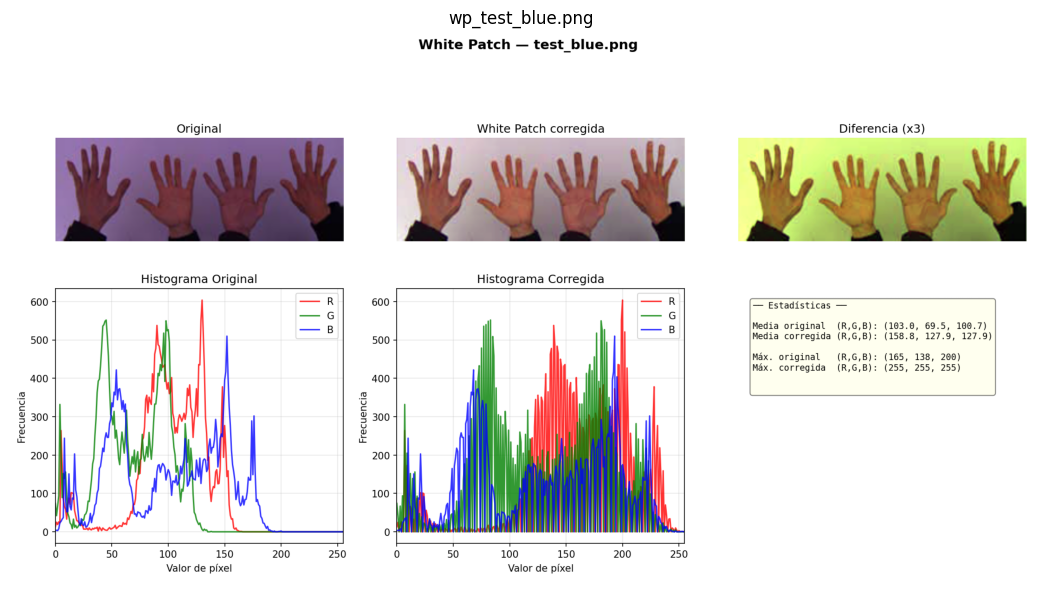

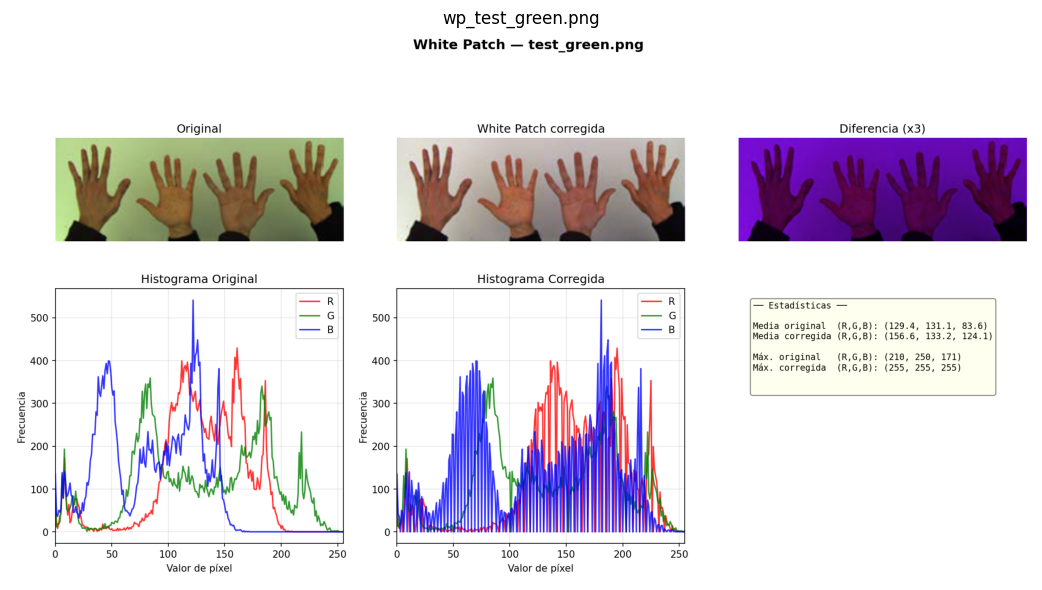

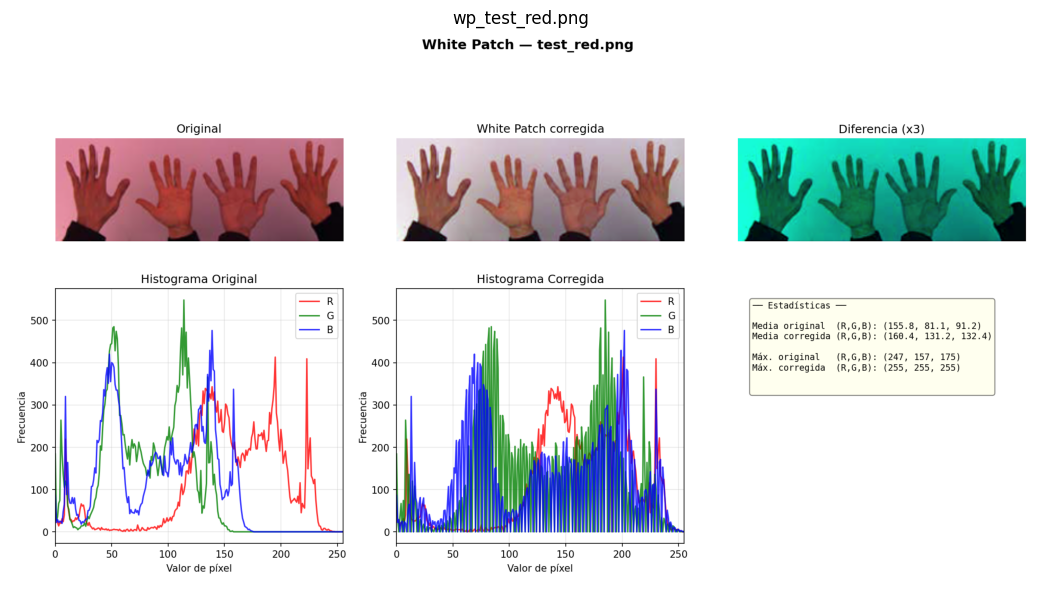

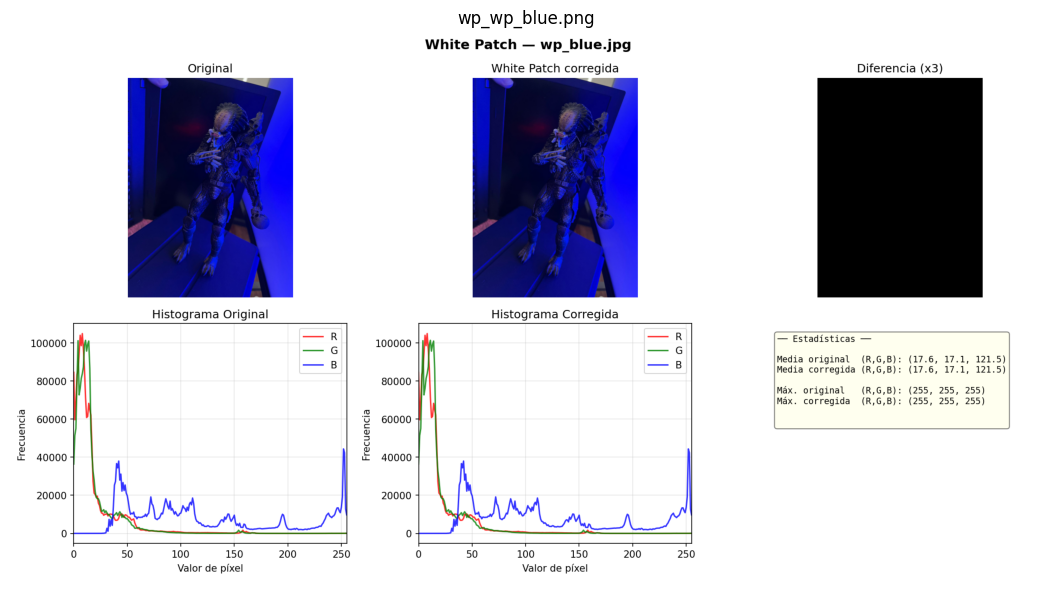

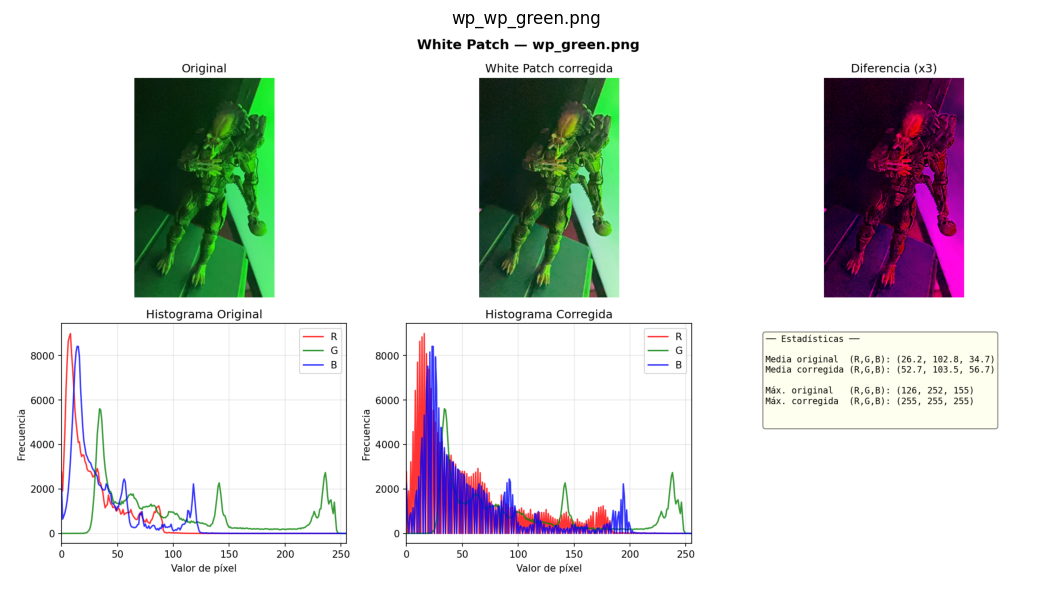

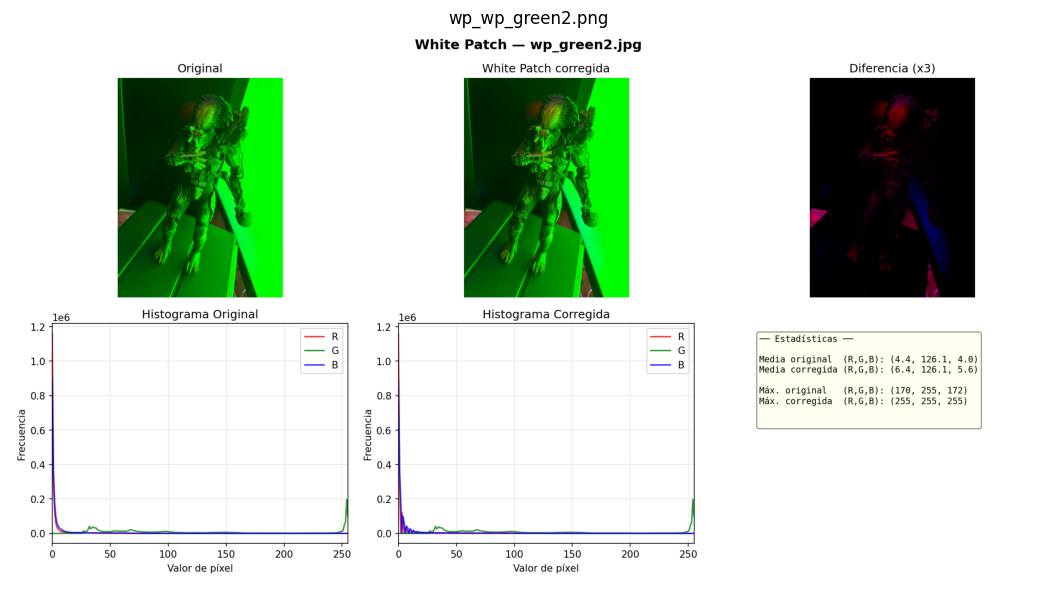

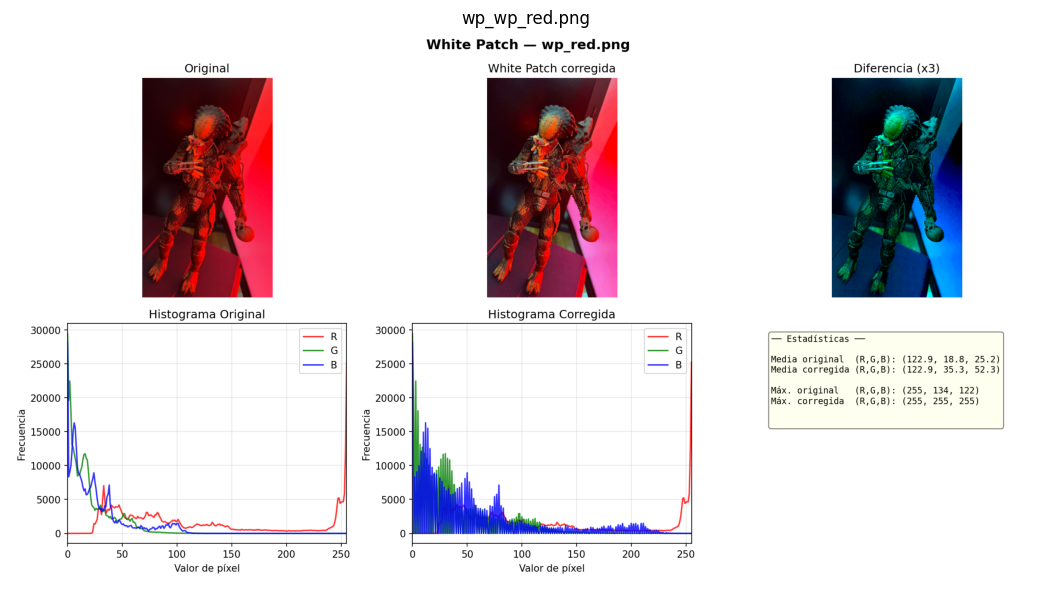

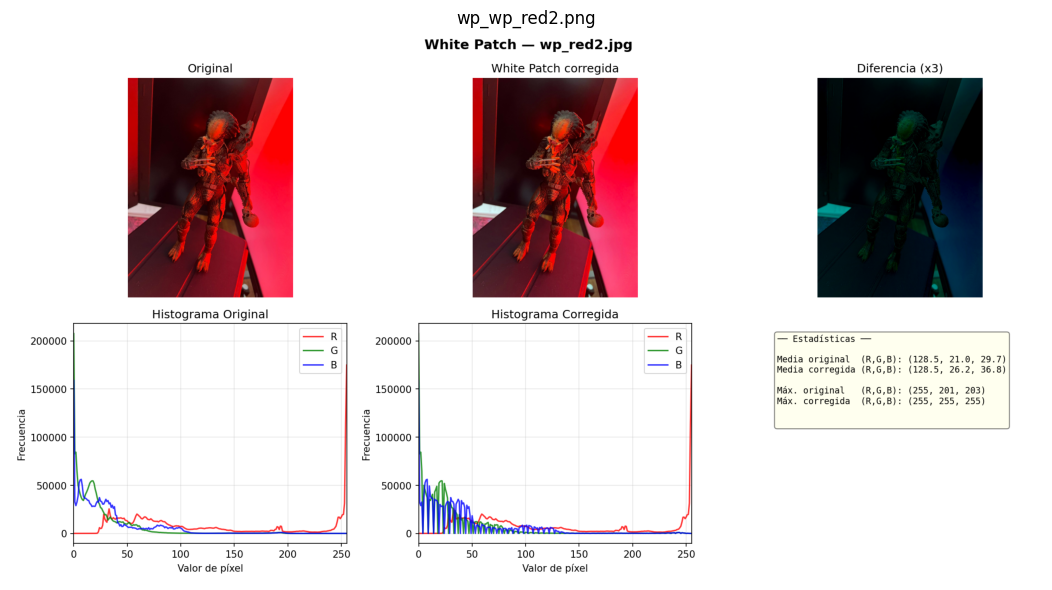

In [26]:
"""
Algoritmo White Patch para corrección de balance de blancos, asume que el píxel más brillante de cada canal es el iluminante
y normaliza la imagen en consecuencia.
"""

#  Configuración para tomar las imágenes del repo
# ─────────────────────────────────────────────
REPO_URL          = "https://github.com/vazquez-agustin/VpC1_Vazquez_Workspace.git"
REPO_NAME         = "/content/VpC1_Vazquez_Workspace/Trabajo_Practico_1"               # nombre de la carpeta que crea git clone
REPO_IMAGE_SUBDIR = "/content/VpC1_Vazquez_Workspace/Trabajo_Practico_1/white_patch"   # subcarpeta dentro del repo con las imágenes
OUTPUT_DIR        = "/content/white_patch_results"
# ─────────────────────────────────────────────

import subprocess, sys, os

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# OpenCV suele estar disponible en Colab, pero por las dudas:
try:
    import cv2
except ImportError:
    install("opencv-python-headless")
    import cv2

import numpy as np
import matplotlib.pyplot as plt



#  Algoritmo White Patch
# ─────────────────────────────────────────────

def white_patch(image: np.ndarray) -> np.ndarray:
  # Se escala cada canal para que su máximo sea 255
  # Convierte a float para evitar saturación en la operación
    img_float = image.astype(np.float32)

    # Calcula el valor máximo por canal (B, G, R)
    max_vals = img_float.max(axis=(0, 1))   # shape: (3,)
    print(f"  Máximo por canal (B, G, R): {max_vals}")

    # Evita división por 0 (canal completamente negro)
    max_vals = np.where(max_vals == 0, 1, max_vals)

    # Escala cada canal a [0, 255]
    corrected = img_float / max_vals * 255.0

    # Clipea y convierte de vuelta a uint8
    corrected = np.clip(corrected, 0, 255).astype(np.uint8)
    return corrected

#  Visualización
# ─────────────────────────────────────────────

def plot_comparison(original: np.ndarray,
                    corrected: np.ndarray,
                    filename: str,
                    output_dir: str) -> None: # Se genera las imagenes del "antes" y "después" y las guarda en la carpeta white_patch_results

    orig_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    corr_rgb = cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"White Patch — {filename}", fontsize=14, fontweight='bold')

    # ── Fila 0: imágenes ──
    axes[0, 0].imshow(orig_rgb)
    axes[0, 0].set_title("Original")
    axes[0, 0].axis('off')

    axes[0, 1].imshow(corr_rgb)
    axes[0, 1].set_title("White Patch corregida")
    axes[0, 1].axis('off')

    # Diferencia absoluta (amplificada x3 para visibilidad)
    diff = np.clip(cv2.absdiff(orig_rgb, corr_rgb).astype(np.float32) * 3, 0, 255).astype(np.uint8)
    axes[0, 2].imshow(diff)
    axes[0, 2].set_title("Diferencia (x3)")
    axes[0, 2].axis('off')

    # ── Fila 1: histogramas ──
    colors = ('red', 'green', 'blue')
    labels_ch = ('R', 'G', 'B')

    for ax, img, title in zip(
        [axes[1, 0], axes[1, 1]],
        [orig_rgb, corr_rgb],
        ["Histograma Original", "Histograma Corregida"]
    ):
        for i, (color, label) in enumerate(zip(colors, labels_ch)):
            hist = cv2.calcHist([img], [i], None, [256], [0, 256])
            ax.plot(hist, color=color, label=label, alpha=0.8)
        ax.set_title(title)
        ax.set_xlim([0, 255])
        ax.set_xlabel("Valor de píxel")
        ax.set_ylabel("Frecuencia")
        ax.legend()
        ax.grid(alpha=0.3)

    # Estadísticas de la corrección en el subplot restante
    ax_stats = axes[1, 2]
    ax_stats.axis('off')

    orig_mean = orig_rgb.mean(axis=(0, 1))
    corr_mean = corr_rgb.mean(axis=(0, 1))
    orig_max  = orig_rgb.max(axis=(0, 1))
    corr_max  = corr_rgb.max(axis=(0, 1))

    stats_text = (
        "── Estadísticas ──\n\n"
        f"Media original  (R,G,B): ({orig_mean[0]:.1f}, {orig_mean[1]:.1f}, {orig_mean[2]:.1f})\n"
        f"Media corregida (R,G,B): ({corr_mean[0]:.1f}, {corr_mean[1]:.1f}, {corr_mean[2]:.1f})\n\n"
        f"Máx. original   (R,G,B): ({orig_max[0]}, {orig_max[1]}, {orig_max[2]})\n"
        f"Máx. corregida  (R,G,B): ({corr_max[0]}, {corr_max[1]}, {corr_max[2]})\n\n"



    )
    ax_stats.text(0.05, 0.95, stats_text, transform=ax_stats.transAxes,
                  fontsize=9, verticalalignment='top', fontfamily='monospace',
                  bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

    plt.tight_layout()
    out_path = os.path.join(output_dir, f"wp_{os.path.splitext(filename)[0]}.png")
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  → Figura guardada: {out_path}")


#  Main
# ─────────────────────────────────────────────

def process_directory(input_dir: str, output_dir: str) -> None:
    os.makedirs(output_dir, exist_ok=True)

    extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif')
    files = [f for f in sorted(os.listdir(input_dir))
             if f.lower().endswith(extensions)]

    if not files:
        print(f"No se encontraron imágenes en '{input_dir}'.")
        return

    print(f"Se encontraron {len(files)} imágenes en '{input_dir}'.\n")

    for fname in files:
        fpath = os.path.join(input_dir, fname)
        print(f"Procesando: {fname}")

        img = cv2.imread(fpath)
        if img is None:
            print(f" No se pudo leer {fname}. Saltando.\n")
            continue

        corrected = white_patch(img)

        # Guarda imagen corregida
        out_img_path = os.path.join(output_dir, f"wp_{fname}")
        cv2.imwrite(out_img_path, corrected)
        print(f"  → Imagen corregida guardada: {out_img_path}")

        # Guardar figura comparativa
        plot_comparison(img, corrected, fname, output_dir)
        print()

    print(" Procesamiento completo.")

repo_local = clone_repo(REPO_URL, REPO_NAME)
input_dir  = os.path.join(repo_local, REPO_IMAGE_SUBDIR)

process_directory(input_dir, OUTPUT_DIR)

# Mostrar resultados inline en el notebook
print("\n── Resultados ──")
result_files = sorted([f for f in os.listdir(OUTPUT_DIR) if f.startswith("wp_") and f.endswith(".png")])
for rf in result_files:
    img_show = cv2.imread(os.path.join(OUTPUT_DIR, rf))
    if img_show is not None:
        plt.figure(figsize=(14, 6))
        plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
        plt.title(rf)
        plt.axis('off')
        plt.tight_layout()
        plt.show()



### Resultados:

**Imagen test_blue:**

La imagen original tiene un fondo (cast) tipo lila-azul pronunciado,los maximos por canal eran R=165, G=138, **B=200** donde se confirma que el azul domina (por eso el fondo de la imagen). Tras la corrección los tres canales se equilibran a 255 cada uno y se puede visualizar en la imagen corregida que los tonos de las manos son mucho mas naturales y el fondo blanquecino.

En la imagen del zoom x3 se ve amarilla-verdosa porque es justamente el complemento del azul removido.

**La corrección fue exitosa**


**Imagen test_green**

La corrección de la imagen es bastante aceptable teniendo encuenta que en los valores originales se encontraba saturado el canal verde
R=210, **G=258**, B=171. y al presentarse este esenario de tener un canal al tope originalmente, el algoritmo no llega a identificar cuanto "sobraba" realmente. La diferencia (×3) se visualiza violeta-magenta que es complemento del verde.


**Imagen test_red**

En los valores máximos originales **R=247**, G=157, B=175 se visualiza que el rojo domina pero no llega alcanzar el tope que es de 255, lo cual podemos decir que es favorable ya que el resultado de la imagen corregida es bueno, el tono de la piel de las manos se ve natural y se modifica el fondo, este resultado es similar al de la primera imagen test_blue.

La diferencia (×3) aparece en tonos cian, complemento del rojo eliminado.



**Imagen wp_blue**

En este caso vemos que los máximos originales de todos los canales ya estaban saturados **R=255, G=255, B=255** por lo cual el algoritmo no realiza ninguna modificación.
Tenemos una falla total, porque la imagen contiene reflejos que saturan todos los canales simultáneamente, haciendo que el "máximo" no represente al iluminante sino a un highlight físico.

**Imagen wp_green**

 En este caso la corrección amplifica el rojo y el azul considerablemente, deonde la imagen corregida recupera algo de detalle, pero en la imagen de diferencia (×3) muestra tonos magenta-rosa algo intensos en zonas que posiblemente deberían ser neutras.

 Como el verde en su máxima original esta en 252 pero el rojo y el azul son mucho más bajos, la amplificación es muy agresiva en esos canales y puede distorsionar colores que originalmente eran verdaderos, por ejemplo, si había un objeto realmente rojo en la escena, quedaría sobre-amplificado.


**Imagen wp_green2**

En este caso la media original es R=4.4, G=126.1, B=4.0 donde el canal verde es mucho más intenso que el rojo y el azul, la imagen corregida sigue luciendo verde porque la corrección solo lleva rojo y azul de ~170 a 255, pero la distribución subyacente de esos canales es casi nula.
Podemos decir que tenemos una falla por dominancia extrema de canal. El algoritmo corrige el pico máximo pero no puede recuperar información que directamente no fue capturada en la exposición original. Se puede visualizar en los histogramas del antes y después que son casi idénticos, con rojo y azul concentrados en valores muy bajos.


**Imagen wp_red**

Acá vemos que el rojo ya está saturado (**R=255**, G=134, B=122), la corrección amplifica verde y azul notablemente:
la media de verde sube de 18.8 a 35.3 y la de azul de 25.2 a 52.3.

La imagen corregida muestra más detalle que la original pero conserva un fondo rojizo porque la distribución real de Rojo es muy diferente a la de verde y azul. En la imagen diferencia (×3) podriamos decir que revela estructuras azul-verdes que no eran visibles. Hay una corrección parcial ya que al estar el canal rojo saturado, el algoritmo no puede saber el verdadero valor del iluminante rojo.

**Imagen wp_red2**

En este caso se visualiza en los histogramas que el canal rojo tiene una distribución enormemente extendida hacia valores altos, mientras que verde y azul están concentrados en valores bajos. Los máximos son (R=255, G=201, B=203), lo que significa que todos los canales tienen algún píxel alto. La corrección visualmente es casi nula, con lo cual podemos decir que tambien hay falla ya que los máximos no representan al iluminante sino a reflejos.

## Parte 2 — Histogramas en escala de grises

1. Leer `img1_tp.png` e `img2_tp.png` con OpenCV en escala de grises y visualizarlas.
2. Graficar sus histogramas, compararlos y analizar si los histogramas pueden ser útiles como *features* para un modelo de clasificación/detección.

In [2]:
%pip install opencv-python-headless

   ---------------------------------------- 0.0/40.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.1 MB ? eta -:--:--
   - -------------------------------------- 1.0/40.1 MB 2.8 MB/s eta 0:00:14
   - -------------------------------------- 1.8/40.1 MB 3.4 MB/s eta 0:00:12
   -- ------------------------------------- 2.6/40.1 MB 3.4 MB/s eta 0:00:11
   ---- ----------------------------------- 4.5/40.1 MB 4.5 MB/s eta 0:00:08
   ------- -------------------------------- 7.3/40.1 MB 6.2 MB/s eta 0:00:06
   --------- ------------------------------ 10.0/40.1 MB 7.1 MB/s eta 0:00:05
   -------------- ------------------------- 14.4/40.1 MB 9.1 MB/s eta 0:00:03
   ----------------- ---------------------- 17.8/40.1 MB 10.0 MB/s eta 0:00:03
   --------------------- ------------------ 21.2/40.1 MB 10.5 MB/s eta 0:00:02
   ------------------------- -------------- 25.4/40.1 MB 11.4 MB/s eta 0:00:02
   ------------------------------ --------- 30.1/40.1 MB 12.3 MB/s eta 0:00:01
   

img1_tp.png — shape: (288, 287), dtype: uint8
img2_tp.png — shape: (288, 287), dtype: uint8


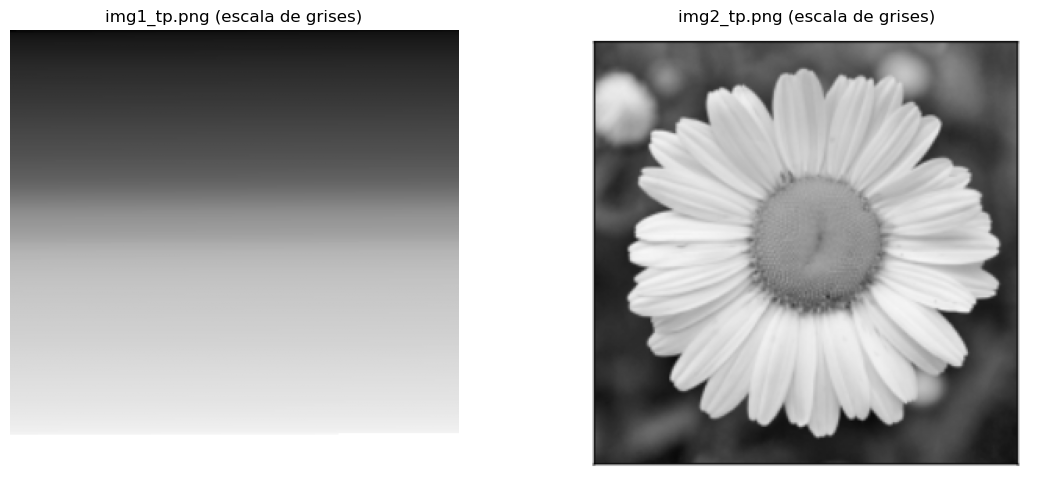

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Ruta base de las imágenes
BASE_DIR = os.path.join(os.getcwd(), "Trabajo_Practico_1")

# Leer imágenes en escala de grises
img1 = cv2.imread(os.path.join(BASE_DIR, "img1_tp.png"), cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(os.path.join(BASE_DIR, "img2_tp.png"), cv2.IMREAD_GRAYSCALE)

print(f"img1_tp.png — shape: {img1.shape}, dtype: {img1.dtype}")
print(f"img2_tp.png — shape: {img2.shape}, dtype: {img2.dtype}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img1, cmap='gray')
axes[0].set_title("img1_tp.png (escala de grises)")
axes[0].axis('off')

axes[1].imshow(img2, cmap='gray')
axes[1].set_title("img2_tp.png (escala de grises)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

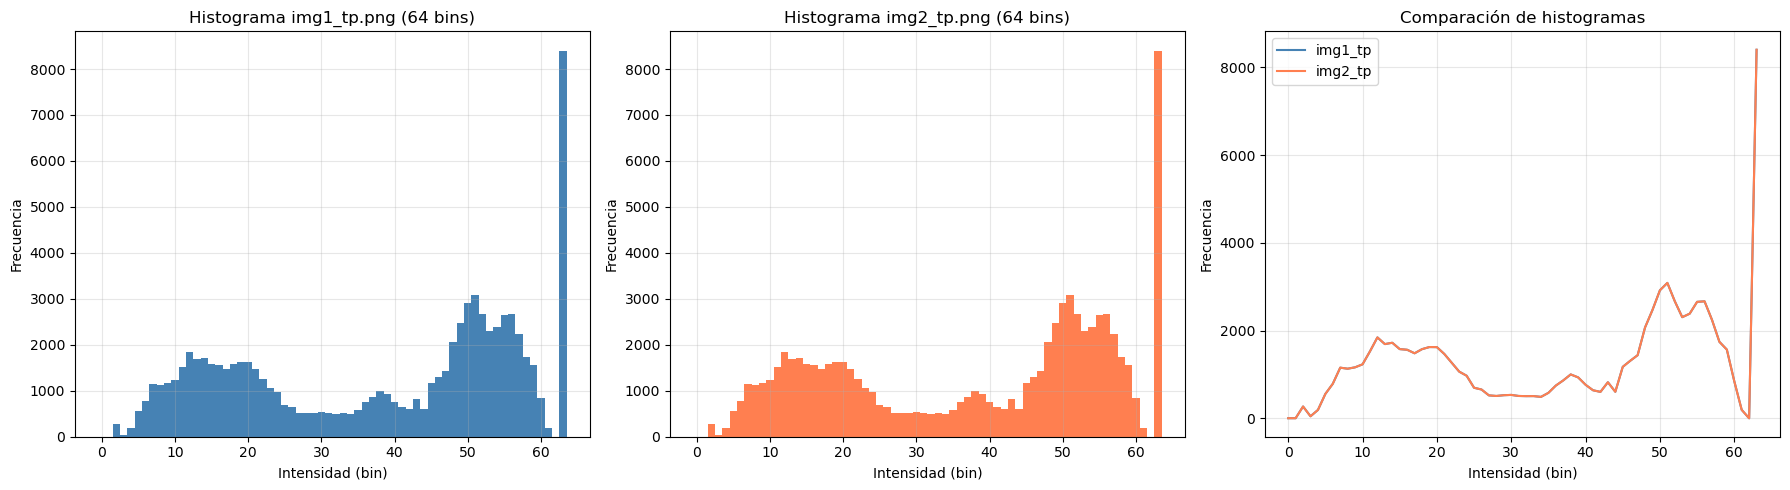

── Estadísticas ──
img1_tp — Media: 154.81, Std: 75.34, Min: 2, Max: 255
img2_tp — Media: 154.81, Std: 75.34, Min: 2, Max: 255

Comparación de histogramas:
  Correlación: 1.0000  (1 = idénticos, -1 = opuestos)
  Chi-cuadrado: 0.00  (0 = idénticos, mayor = más diferentes)


In [4]:
# Número de bins elegido: 64
# Se elige 64 bins (en lugar de 256) para suavizar el histograma y facilitar
# la comparación visual entre ambas imágenes, reduciendo el ruido estadístico.
NUM_BINS = 64

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma img1
hist1 = cv2.calcHist([img1], [0], None, [NUM_BINS], [0, 256])
axes[0].bar(range(NUM_BINS), hist1.flatten(), color='steelblue', width=1.0)
axes[0].set_title(f"Histograma img1_tp.png ({NUM_BINS} bins)")
axes[0].set_xlabel("Intensidad (bin)")
axes[0].set_ylabel("Frecuencia")
axes[0].grid(alpha=0.3)

# Histograma img2
hist2 = cv2.calcHist([img2], [0], None, [NUM_BINS], [0, 256])
axes[1].bar(range(NUM_BINS), hist2.flatten(), color='coral', width=1.0)
axes[1].set_title(f"Histograma img2_tp.png ({NUM_BINS} bins)")
axes[1].set_xlabel("Intensidad (bin)")
axes[1].set_ylabel("Frecuencia")
axes[1].grid(alpha=0.3)

# Comparación superpuesta
axes[2].plot(hist1, color='steelblue', label='img1_tp', linewidth=1.5)
axes[2].plot(hist2, color='coral', label='img2_tp', linewidth=1.5)
axes[2].set_title("Comparación de histogramas")
axes[2].set_xlabel("Intensidad (bin)")
axes[2].set_ylabel("Frecuencia")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas
print("── Estadísticas ──")
print(f"img1_tp — Media: {img1.mean():.2f}, Std: {img1.std():.2f}, Min: {img1.min()}, Max: {img1.max()}")
print(f"img2_tp — Media: {img2.mean():.2f}, Std: {img2.std():.2f}, Min: {img2.min()}, Max: {img2.max()}")

# Correlación entre histogramas
corr = cv2.compareHist(hist1.astype(np.float32), hist2.astype(np.float32), cv2.HISTCMP_CORREL)
chi2 = cv2.compareHist(hist1.astype(np.float32), hist2.astype(np.float32), cv2.HISTCMP_CHISQR)
print(f"\nComparación de histogramas:")
print(f"  Correlación: {corr:.4f}  (1 = idénticos, -1 = opuestos)")
print(f"  Chi-cuadrado: {chi2:.2f}  (0 = idénticos, mayor = más diferentes)")

### Análisis de los histogramas

**Observaciones:**

Los histogramas de `img1_tp.png` (un gradiente suave) e `img2_tp.png` (una flor) son **idénticos**: correlación = 1.0 y chi-cuadrado = 0.0. Ambas imágenes comparten exactamente la misma media (154.81), desviación estándar (75.34), mínimo (2) y máximo (255). Esto demuestra que dos imágenes con contenido visual completamente distinto pueden tener la misma distribución de intensidades.

La imagen del gradiente distribuye sus píxeles de forma uniforme a lo largo de los 256 niveles de gris, y la imagen de la flor —con sus pétalos blancos, centro oscuro y fondo gris— genera una distribución de intensidades equivalente, lo que produce histogramas superpuestos e indistinguibles.

**¿Los histogramas son útiles como features para clasificación/detección?**

Este ejemplo demuestra una limitación fundamental: los histogramas **pierden toda la información espacial**. Dado que los histogramas solo cuentan la frecuencia de cada nivel de intensidad sin considerar la posición de los píxeles, imágenes con estructura completamente diferente pueden producir histogramas idénticos como queda evidenciado en este caso.

- **Ventajas:** Capturan la distribución global de intensidades, son invariantes a traslación y rotación, y son computacionalmente baratos. Pueden ser útiles para distinguir escenas con distribuciones de brillo muy distintas (escena nocturna vs. diurna) o como feature complementario.

- **Limitaciones:** Al perder la información espacial, no pueden distinguir entre imágenes con el mismo histograma pero contenido visual diferente (como en este caso). Son insuficientes para tareas de detección de objetos o clasificación fina.

- **Conclusión:** Los histogramas **no son suficientes por sí solos** como features para un modelo de clasificación/detección. Deben combinarse con descriptores que capturen información espacial y de textura (HOG, SIFT, LBP, o features aprendidas por redes convolucionales).